In [1]:
import pandas as pd 
import numpy as np
from collections import defaultdict
import sys
sys.path.append('/Users/fido_josephine/Documents/New-Fraud-Rules/fraud')
from modules.distance_finder import lev_win_multi, lev_win_distance, jaro_win_multi, lev_win_multi_weighted
from modules.group_dr import add_multi_chart
df = pd.read_csv('IOS Fraud UG  (1).csv')
df['SURVEY_DATE'] = pd.to_datetime(df['TIME'])

In [2]:
df.head()

,TIME,HASH4,HASH5,PLATFORM,GROUPS,FRAUD_AREA,CLIENT_ID,ADDRESS,AGE,AIRTEL_WALLET,...,EMPLOYMENT,INCOME_VALUE,INDUSTRY,POSITION,POSLEN,REFERENCE1_PHONE_NUMBER,DISIBURSED,LOANAMOUNT,DR1,SURVEY_DATE
0,2025-02-01 00:00:00.000,kxvu,kxvu3,ios,CG,0,561324958,ngomba ruzinga,57,True,...,Employed full-time,"700,001 - 1,000,000 UGX",Construction,Truck driver,13,256772404867,1,45000.0,1,2025-02-01
1,2025-03-01 00:00:00.000,kxvu,kxvud,ios,CG,0,823318285,Ruhaama 2,47,True,...,Employed full-time,"700,001 - 1,000,000 UGX",Trade - Wholesale,Sales manager,14,256782667312,1,45000.0,1,2025-03-01
2,2025-03-01 00:00:00.000,kxvg,kxvge,ios,CG,0,31912050,kagarama rwakashaka,23,True,...,Employed full-time,"700,001 - 1,000,000 UGX",Trade - Wholesale,Sales manager,14,256740892947,1,45000.0,1,2025-03-01
3,2025-01-01 00:00:00.000,s8j3,s8j3s,ios,CG,0,59562690,nyakasanga road,61,False,...,Self-employed,"350,001 - 700,000 UGX",Agriculture,Farmer,6,256777573716,1,45000.0,1,2025-01-01
4,2025-01-01 00:00:00.000,kxyr,kxyr8,ios,CG,0,283642761,6th street,27,False,...,Self-employed,"700,001 - 1,000,000 UGX",Agriculture,farmer,6,256776998329,1,45000.0,1,2025-01-01


In [3]:
df['HASH'] = df['HASH4']
df['DISBURSED'] = df['DISIBURSED']
df = df.drop('TIME', axis=1)

In [4]:
records = []
for i in range(2, 7):
    for j in range(1, 3):
        output = defaultdict(list) 
        res = lev_win_distance(df, 15, i, j)
        res['dup_limit'] = i    
        output['dup_limit'] = i
        output['sim_threshold'] =j
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)
address_dup_fraud = res.copy()

output1 = pd.DataFrame(records)

/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_50980/3997120446.py:11: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_50980/3997120446.py:11: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_50980/3997120446.py:11: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()


In [5]:
from modules.distance_finder import jaro_win

In [7]:
records = []
for i in range(2, 7):
    output = defaultdict(list) 
    res = jaro_win(df, 15, i, 0.75)
    res['dup_limit'] = i    
    output['dup_limit'] = i
    output['sim_threshold'] = 0.75
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)
address_dup_fraud = res.copy()

output1 = pd.DataFrame(records)

In [8]:
output1

,dup_limit,sim_threshold,n_surveys,n_disbursed,dr
0,2,0.75,57,57,0.947368
1,3,0.75,45,45,0.955556
2,4,0.75,27,27,1.000000
3,5,0.75,21,21,1.000000
4,6,0.75,13,13,1.000000


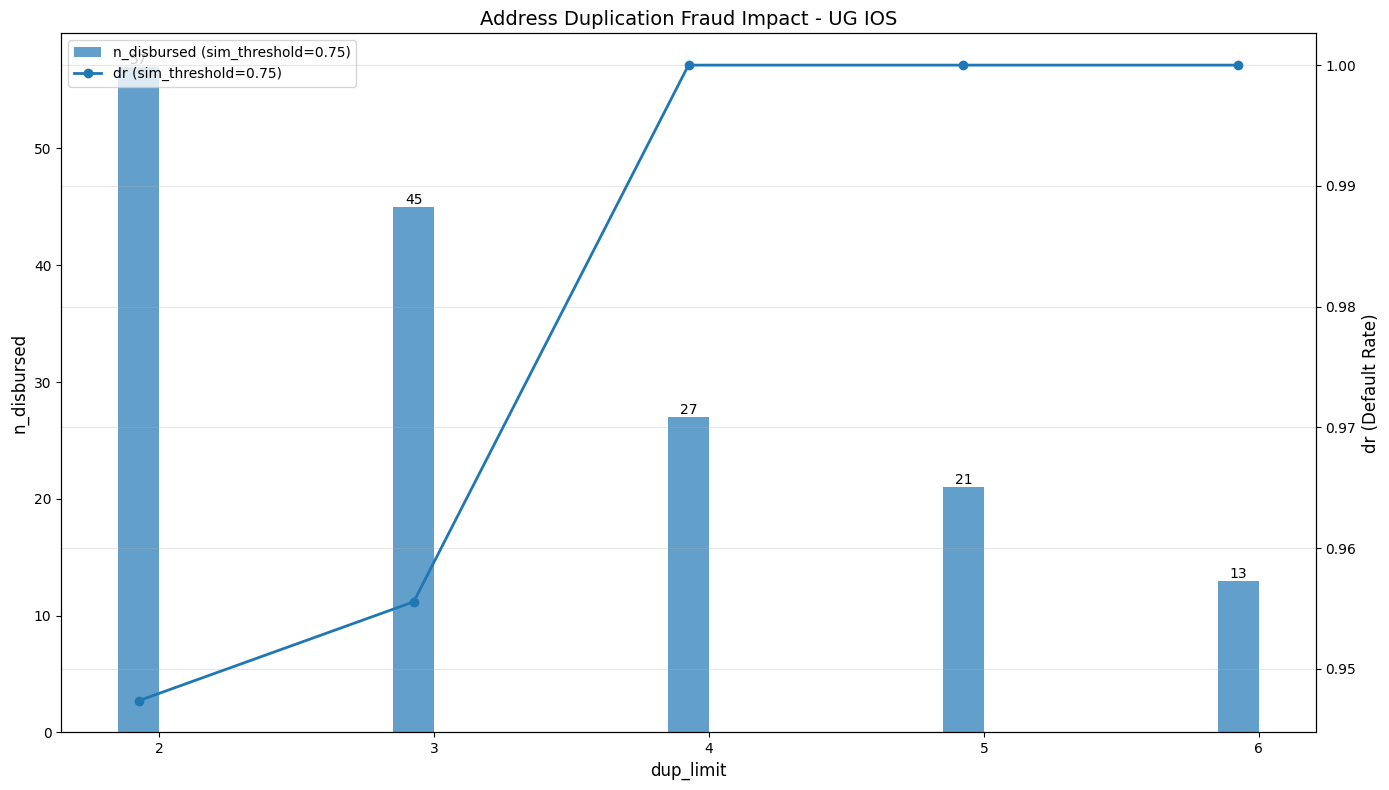

In [9]:
add_multi_chart(output1, 'Address Duplication Fraud Impact - UG IOS', 'dup_limit', 'sim_threshold')

In [10]:
records = []
for i in range(2, 7):
    output = defaultdict(list) 
    res = jaro_win_multi(df, 15, 0.75, 0.75, i)
    res['dup_limit'] = i    
    output['dup_limit'] = i
    output['sim_threshold'] = 0.75
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)
address_dup_fraud = res.copy()

output1 = pd.DataFrame(records)

/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_50980/2134708621.py:10: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_50980/2134708621.py:10: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_50980/2134708621.py:10: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_50980/2134708621.py:10: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_50980/2134708621.py:10: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()


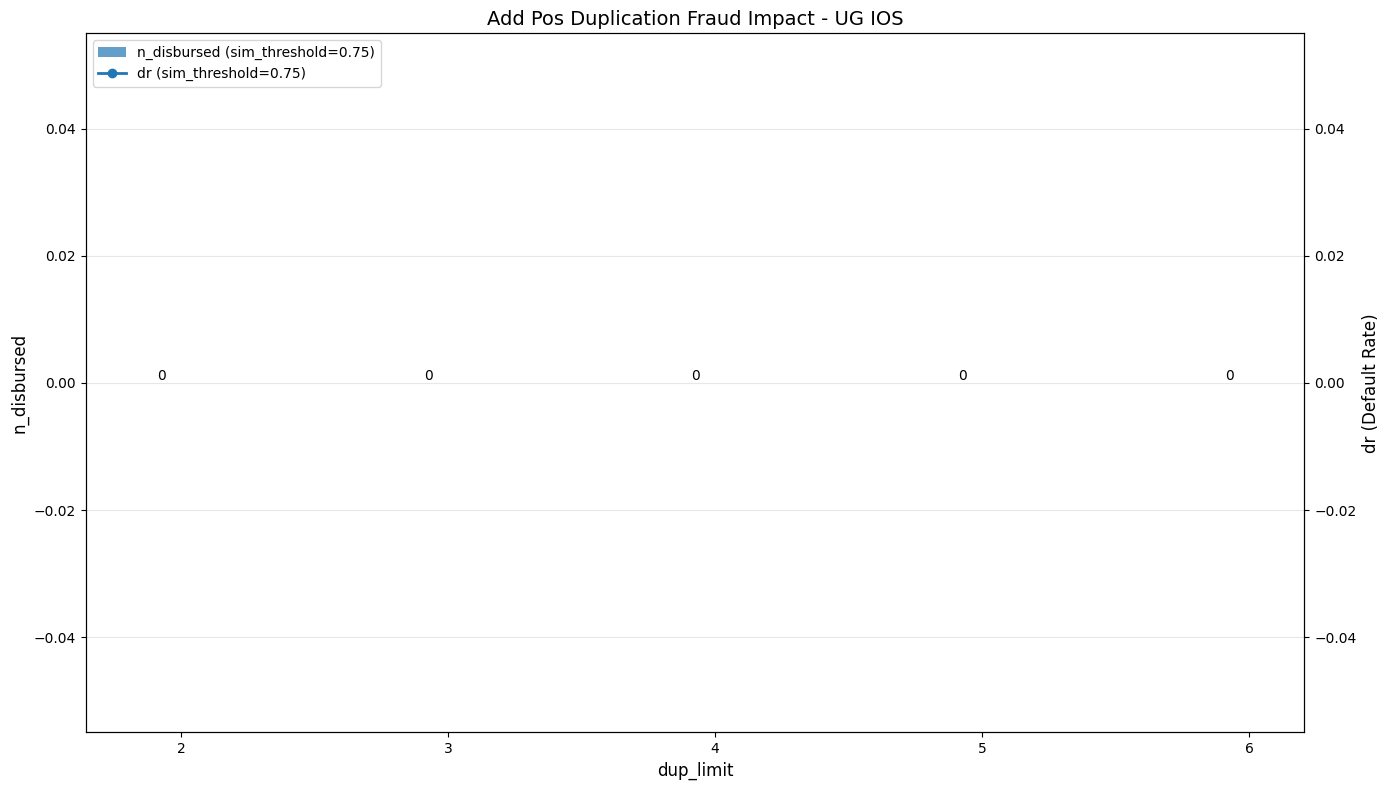

In [12]:
output1
add_multi_chart(output1, 'Add Pos Duplication Fraud Impact - UG IOS', 'dup_limit', 'sim_threshold')


In [13]:
records = []
for i in range(2, 6):
    #for j in [0.75, 0.80, 0.85]:
    output = defaultdict(list) 
    res = lev_win_multi(df, 15, 3, 4, i)
    res['dup_limit'] = i
    # res['pos_sim'] = j
    output['dup_limit'] = i
    # output['pos_sim'] = j
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)

/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_46079/4133758369.py:12: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_46079/4133758369.py:12: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_46079/4133758369.py:12: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_46079/4133758369.py:12: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()


In [14]:
output3 = pd.DataFrame(records)

In [15]:
output3

,dup_limit,n_surveys,n_disbursed,dr
0,2,0,0,NaN
1,3,0,0,NaN
2,4,0,0,NaN
3,5,0,0,NaN


In [5]:
records = []
for i in range(3, 6):
    for j in range(2, 10):
        output = defaultdict(list) 
        res = lev_pos_win(df, 15, j, i)
        output['dup_limit'] = j
        output['pos_sim'] = i
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)

output1 = pd.DataFrame(records)

In [6]:
output1

,dup_limit,pos_sim,n_surveys,n_disbursed,dr
0,2,3,79,79,0.974684
1,3,3,58,58,0.965517
2,4,3,51,51,0.960784
3,5,3,41,41,0.951220
4,6,3,34,34,0.941176
5,7,3,21,21,1.000000
6,8,3,20,20,1.000000
7,9,3,15,15,1.000000
8,2,4,102,102,0.941176
9,3,4,86,86,0.930233


In [7]:
import matplotlib.pyplot as plt

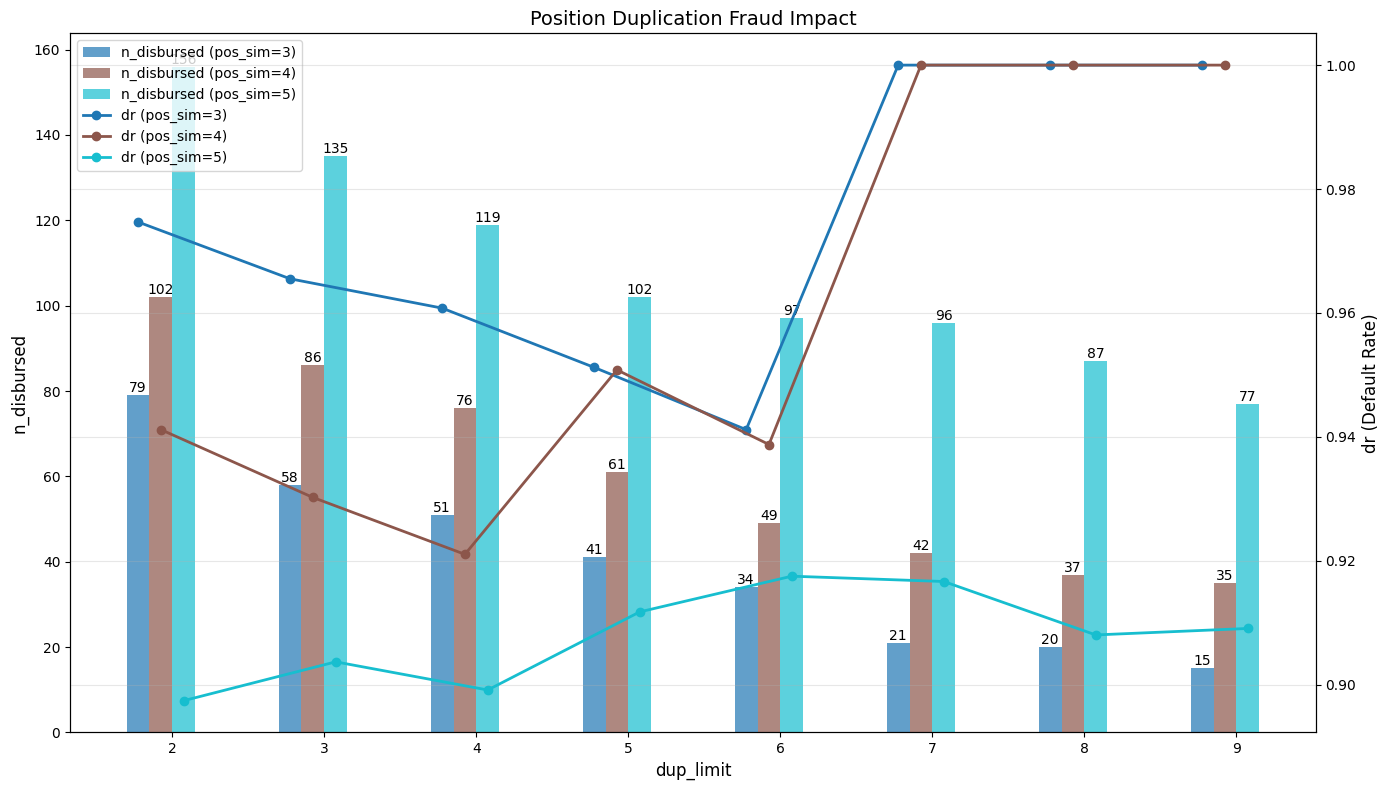

In [7]:
add_multi_chart(output1, 'Position Duplication Fraud Impact', 'dup_limit', 'pos_sim')

In [8]:

records = []
for i in range(2, 10):
    for j in (2, 5, 10, 15):
        output = defaultdict(list) 
        res = lev_win_multi(df, 15, i, 6, 2)
        output['add_sim'] = i
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)
results = pd.DataFrame(records)


/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_17246/1761060173.py:9: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_17246/1761060173.py:9: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_17246/1761060173.py:9: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_17246/1761060173.py:9: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_17246/1761060173.py:9: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folde

In [9]:
results.head()

,add_sim,n_surveys,n_disbursed,dr
0,2,0,0,NaN
1,2,0,0,NaN
2,2,0,0,NaN
3,2,0,0,NaN
4,3,0,0,NaN


Position + Industry Duplication

In [10]:

records = []
for i in range(1, 5):
    for j in range(2, 6):
        output = defaultdict(list) 
        res = lev_win_pos_ind(df, 15, i,  j)
        output['pos_sim'] = i
        output['dup_limit'] = j
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)
results = pd.DataFrame(records)

In [11]:
results.head()

,pos_sim,dup_limit,n_surveys,n_disbursed,dr
0,1,2,61,61,0.967213
1,1,3,44,44,0.954545
2,1,4,34,34,0.941176
3,1,5,28,28,0.928571
4,2,2,63,63,0.968254


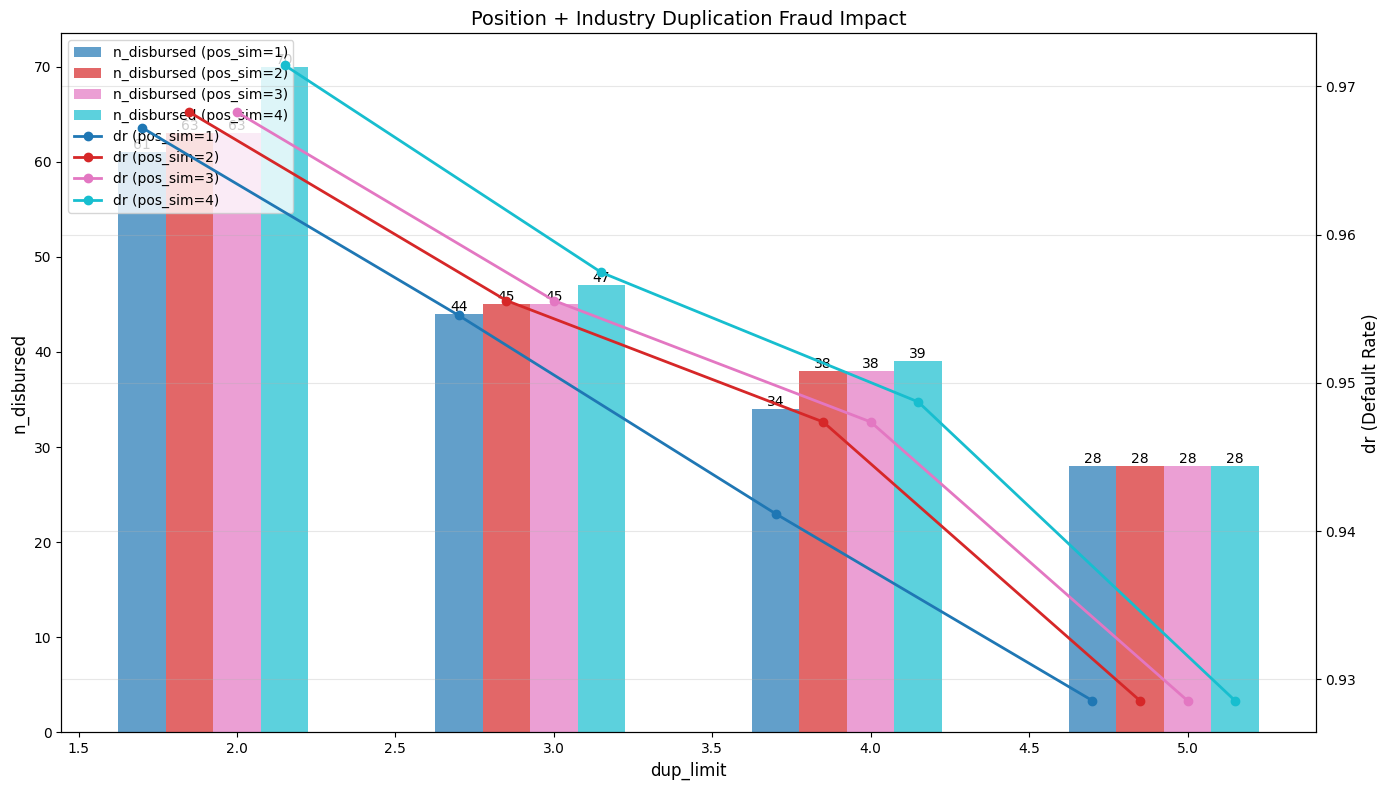

In [12]:
add_multi_chart(results, 'Position + Industry Duplication Fraud Impact', 'dup_limit', 'pos_sim')

In [15]:
records = []
for i in range(5, 10):
    for j in range(2, 6):
        output = defaultdict(list) 
        res = lev_win_pos_ind(df, 15, i,  j)
        output['pos_sim'] = i
        output['dup_limit'] = j
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)
results = pd.DataFrame(records)

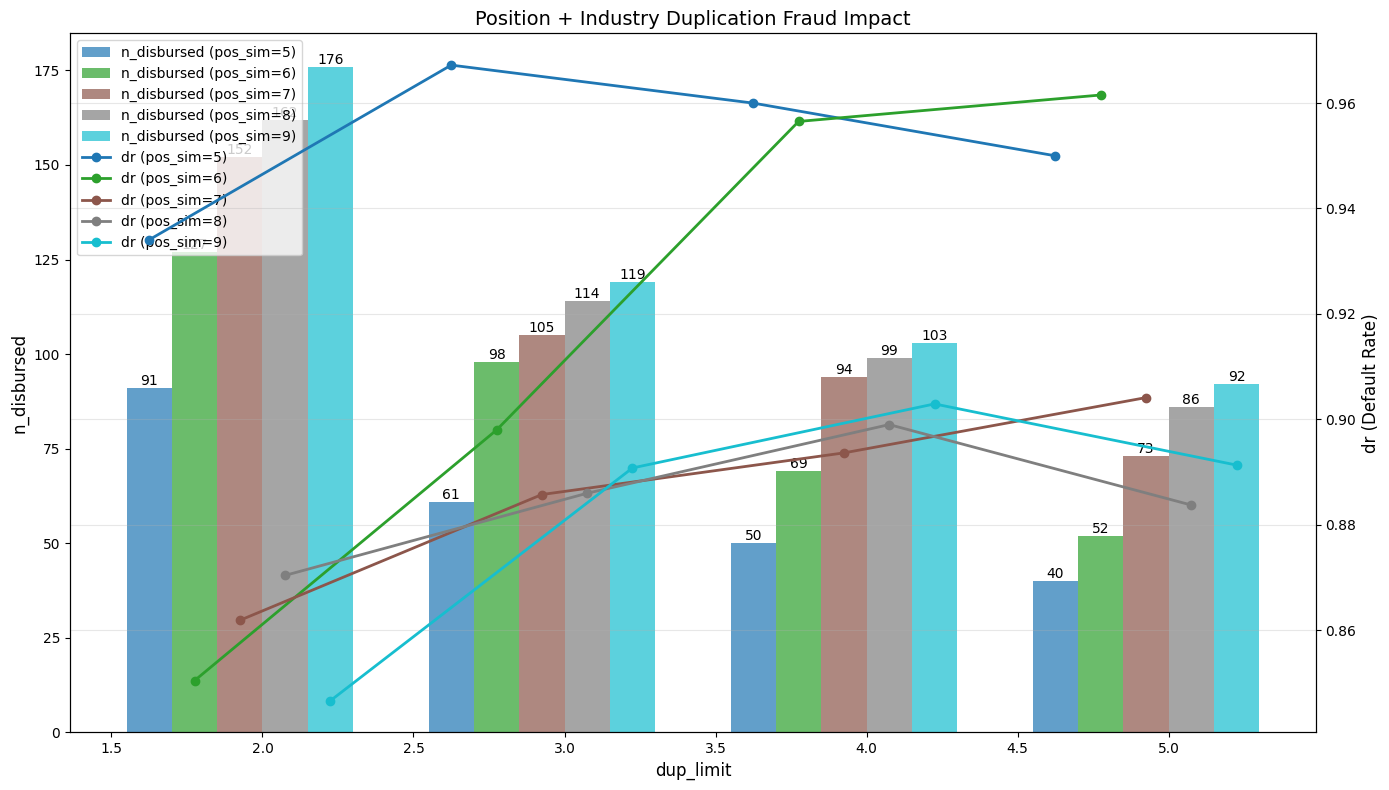

In [16]:
add_multi_chart(results, 'Position + Industry Duplication Fraud Impact', 'dup_limit', 'pos_sim')